# **Imports**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import io
from sklearn.impute import KNNImputer
from IPython.display import display
import sys
import missingno as msno
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline



pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

# **Initial Inspection**

In [39]:
file_path = 'ACME-HappinessSurvey2020.csv'
df = pd.read_csv(file_path)

In [40]:
df.columns = ['customer_happiness', 'delivery_timeliness','order_accuracy','product_availability', 'price_value_perception','courier_service_rating', 'app_usability']

In [41]:
display(df.head())
display(df.tail())

,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
121,1,5,2,3,4,4,3
122,1,5,2,3,4,2,5
123,1,5,3,3,4,4,5
124,0,4,3,3,4,4,5
125,0,5,3,2,5,5,5


In [42]:
print('=== SHAPE ===')
print(df.shape,'\n')
print('=== DTYPES ===')
print(df.dtypes, '\n')
print('=== NULLS ===')
print(df.isnull().sum(), '\n')
print('=== DUPES ===')
print(df.duplicated().sum(), '\n')
print('=== DESCRIBE ===')
display(df.describe(include='all'))

=== SHAPE ===
(126, 7) 

=== DTYPES ===
customer_happiness        int64
delivery_timeliness       int64
order_accuracy            int64
product_availability      int64
price_value_perception    int64
courier_service_rating    int64
app_usability             int64
dtype: object 

=== NULLS ===
customer_happiness        0
delivery_timeliness       0
order_accuracy            0
product_availability      0
price_value_perception    0
courier_service_rating    0
app_usability             0
dtype: int64 

=== DUPES ===
16 

=== DESCRIBE ===


,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
count,126.0000,126.0000,126.0000,126.0000,126.0000,126.0000,126.0000
mean,0.5476,4.3333,2.5317,3.3095,3.7460,3.6508,4.2540
std,0.4997,0.8000,1.1149,1.0234,0.8758,1.1476,0.8093
min,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
25%,0.0000,4.0000,2.0000,3.0000,3.0000,3.0000,4.0000
50%,1.0000,5.0000,3.0000,3.0000,4.0000,4.0000,4.0000
75%,1.0000,5.0000,3.0000,4.0000,4.0000,4.0000,5.0000
max,1.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000


# **Data Quality Check**

In [43]:
df.drop_duplicates(inplace=True)

print(f'Clean shape: {df.shape}')

Clean shape: (110, 7)


# **Anomaly Detection and Handling**

In [44]:
for col in ['delivery_timeliness','order_accuracy','product_availability','price_value_perception','courier_service_rating', 'app_usability']:
    assert df[col].between(1, 5).all(), f'{col} has out-of-range values'
assert df['customer_happiness'].isin([0, 1]).all(), 'Y has non-binary values'
print('All values within expected ranges.')

All values within expected ranges.


# **Univariate Analysis**

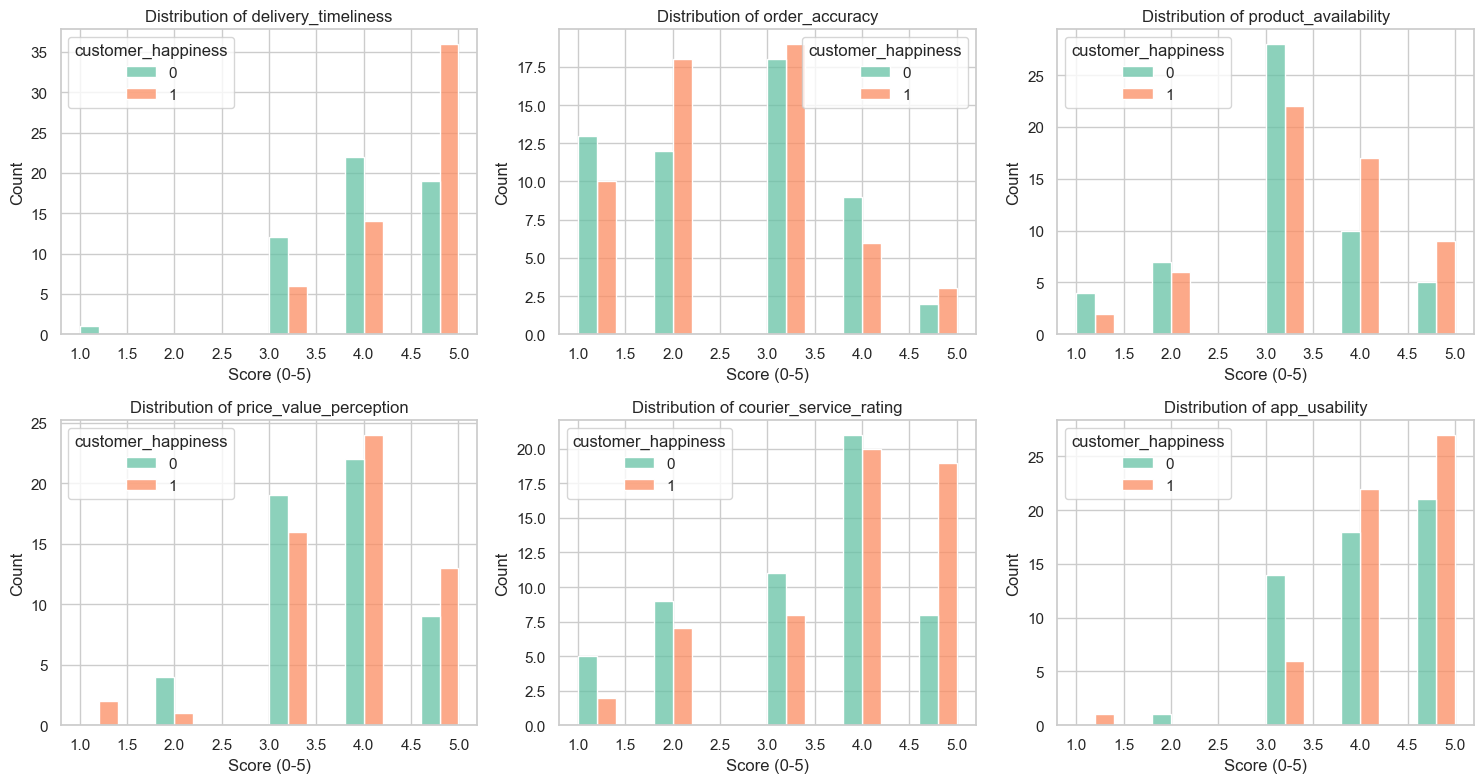

In [45]:
# Distribution of each feature by class
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, feature in enumerate(df.drop('customer_happiness', axis=1).columns):
    sns.histplot(
        data=df, 
        x=feature, 
        hue='customer_happiness', 
        ax=axes[idx],
        multiple='dodge',
    )
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel('Score (0-5)')

plt.tight_layout()
plt.show()

# **Correlation Matrix and VIF**

In [46]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

corr = df.corr(method='pearson')
display(corr.style.background_gradient(cmap='coolwarm'))

X = df[['delivery_timeliness','order_accuracy','product_availability','price_value_perception','courier_service_rating','app_usability']]
X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif['feature'] = X_const.columns
vif['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif)

,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
customer_happiness,1.000000,0.286268,-0.000601,0.175445,0.076802,0.213360,0.137457
delivery_timeliness,0.286268,1.000000,0.059029,0.265379,0.100773,0.436698,0.405007
order_accuracy,-0.000601,0.059029,1.000000,0.203985,0.107055,0.056668,-0.102544
product_availability,0.175445,0.265379,0.203985,1.000000,0.262152,0.313917,0.170391
price_value_perception,0.076802,0.100773,0.107055,0.262152,1.000000,0.267937,0.221417
courier_service_rating,0.213360,0.436698,0.056668,0.313917,0.267937,1.000000,0.307837
app_usability,0.137457,0.405007,-0.102544,0.170391,0.221417,0.307837,1.000000


                  feature     VIF
0                   const 54.2018
1     delivery_timeliness  1.4167
2          order_accuracy  1.0779
3    product_availability  1.2222
4  price_value_perception  1.1617
5  courier_service_rating  1.3788
6           app_usability  1.2989


# T-Tests

In [47]:
means = df.groupby('customer_happiness').mean().T
means.columns = ['Unhappy (mean)', 'Happy (mean)']
means['Difference'] = means['Happy (mean)'] - means['Unhappy (mean)']
means = means.sort_values('Difference', ascending=False)
print("=== MEAN COMPARISON: Feature Predictive Power ===")
print(means.round(2))

=== MEAN COMPARISON: Feature Predictive Power ===
                        Unhappy (mean)  Happy (mean)  Difference
courier_service_rating          3.3300        3.8400      0.5100
delivery_timeliness             4.0700        4.5400      0.4600
product_availability            3.0900        3.4500      0.3500
app_usability                   4.0900        4.3200      0.2300
price_value_perception          3.6700        3.8000      0.1400
order_accuracy                  2.5400        2.5400     -0.0000


In [48]:
from scipy.stats import ttest_ind, mannwhitneyu

happy = df[df['customer_happiness'] == 1]
unhappy = df[df['customer_happiness'] == 0]

results = []

for col in df.drop('customer_happiness', axis=1).columns:
    t_stat, p_ttest = ttest_ind(happy[col], unhappy[col], equal_var=False)  # Welch's t-test
    u_stat, p_mwu = mannwhitneyu(happy[col], unhappy[col], alternative='two-sided') # Mann-Whitney U (non-parametric)
    
    results.append({
        'feature': col,
        'mean_happy': happy[col].mean().round(2),
        'mean_unhappy': unhappy[col].mean().round(2),
        'mean_diff': (happy[col].mean() - unhappy[col].mean()).round(2),
        'p_ttest': p_ttest.round(4),
        'p_mwu': p_mwu.round(4),
        'significant': p_mwu < 0.05  # Using Mann-Whitney U for decision
    })

results_df = pd.DataFrame(results).sort_values('mean_diff', ascending=False)
print("=== STATISTICAL SIGNIFICANCE OF FEATURE DIFFERENCES ===")
print(results_df.to_string(index=False))

=== STATISTICAL SIGNIFICANCE OF FEATURE DIFFERENCES ===
               feature  mean_happy  mean_unhappy  mean_diff  p_ttest  p_mwu  significant
courier_service_rating      3.8400        3.3300     0.5100   0.0254 0.0197         True
   delivery_timeliness      4.5400        4.0700     0.4600   0.0026 0.0022         True
  product_availability      3.4500        3.0900     0.3500   0.0667 0.0586        False
         app_usability      4.3200        4.0900     0.2300   0.1525 0.1255        False
price_value_perception      3.8000        3.6700     0.1400   0.4243 0.2948        False
        order_accuracy      2.5400        2.5400    -0.0000   0.9950 0.9284        False


# Model Eval

In [49]:
X = df.drop(columns=['customer_happiness'])
y = df['customer_happiness']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [50]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=2, min_samples_leaf=10,class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(max_depth=3, n_estimators=100,class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=42, scale_pos_weight=1)
}

In [51]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append(
    {"Model Name": name, 
    "F1 Score with Test Data": classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score'],
    "Accuracy with Test Data": classification_report(y_test, y_pred, output_dict=True)['accuracy']
    })
results_df = pd.DataFrame(results).sort_values('Accuracy with Test Data', ascending=False)
print("=== MODEL PERFORMANCE COMPARISON ===")
print(results_df.to_string(index=False))

=== MODEL PERFORMANCE COMPARISON ===
         Model Name  F1 Score with Test Data  Accuracy with Test Data
      Decision Tree                   0.6429                   0.6429
      Random Forest                   0.6066                   0.6071
Logistic Regression                   0.5692                   0.5714
            XGBoost                   0.5351                   0.5357


# XG Boost Fine

In [52]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)

xgb_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4],  
    "learning_rate": [0.1, 0.2, 0.3],
    "min_child_weight": [5, 10],

}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
y_pred_xgb = xgb_grid.predict(X_test)

print(f"Best parameters: {xgb_grid.best_params_}")
print(f"Best cross-validation accuracy: {xgb_grid.best_score_:.2%}")
print(f"Test F1 score: {f1_score(y_test, y_pred_xgb):.2%}")
print(f"Test accuracy: {xgb_grid.score(X_test, y_test):.2%}")

Best parameters: {'learning_rate': 0.2, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 200}
Best cross-validation accuracy: 59.71%
Test F1 score: 66.67%
Test accuracy: 60.71%


# Random Forest

In [53]:
rf = RandomForestClassifier(max_depth=3, n_estimators=100,class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
perm_result= permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Gini Importance': importances,
    'Permutation Importance': perm_result.importances_mean})
print("=== FEATURE IMPORTANCE FROM RANDOM FOREST ===")
print(feature_importance_df.sort_values('Gini Importance', ascending=False).to_string(index=False))

=== FEATURE IMPORTANCE FROM RANDOM FOREST ===
               Feature  Gini Importance  Permutation Importance
   delivery_timeliness           0.2488                  0.1107
price_value_perception           0.1747                 -0.0214
courier_service_rating           0.1632                 -0.0036
  product_availability           0.1580                 -0.0143
        order_accuracy           0.1349                  0.0143
         app_usability           0.1204                 -0.0179


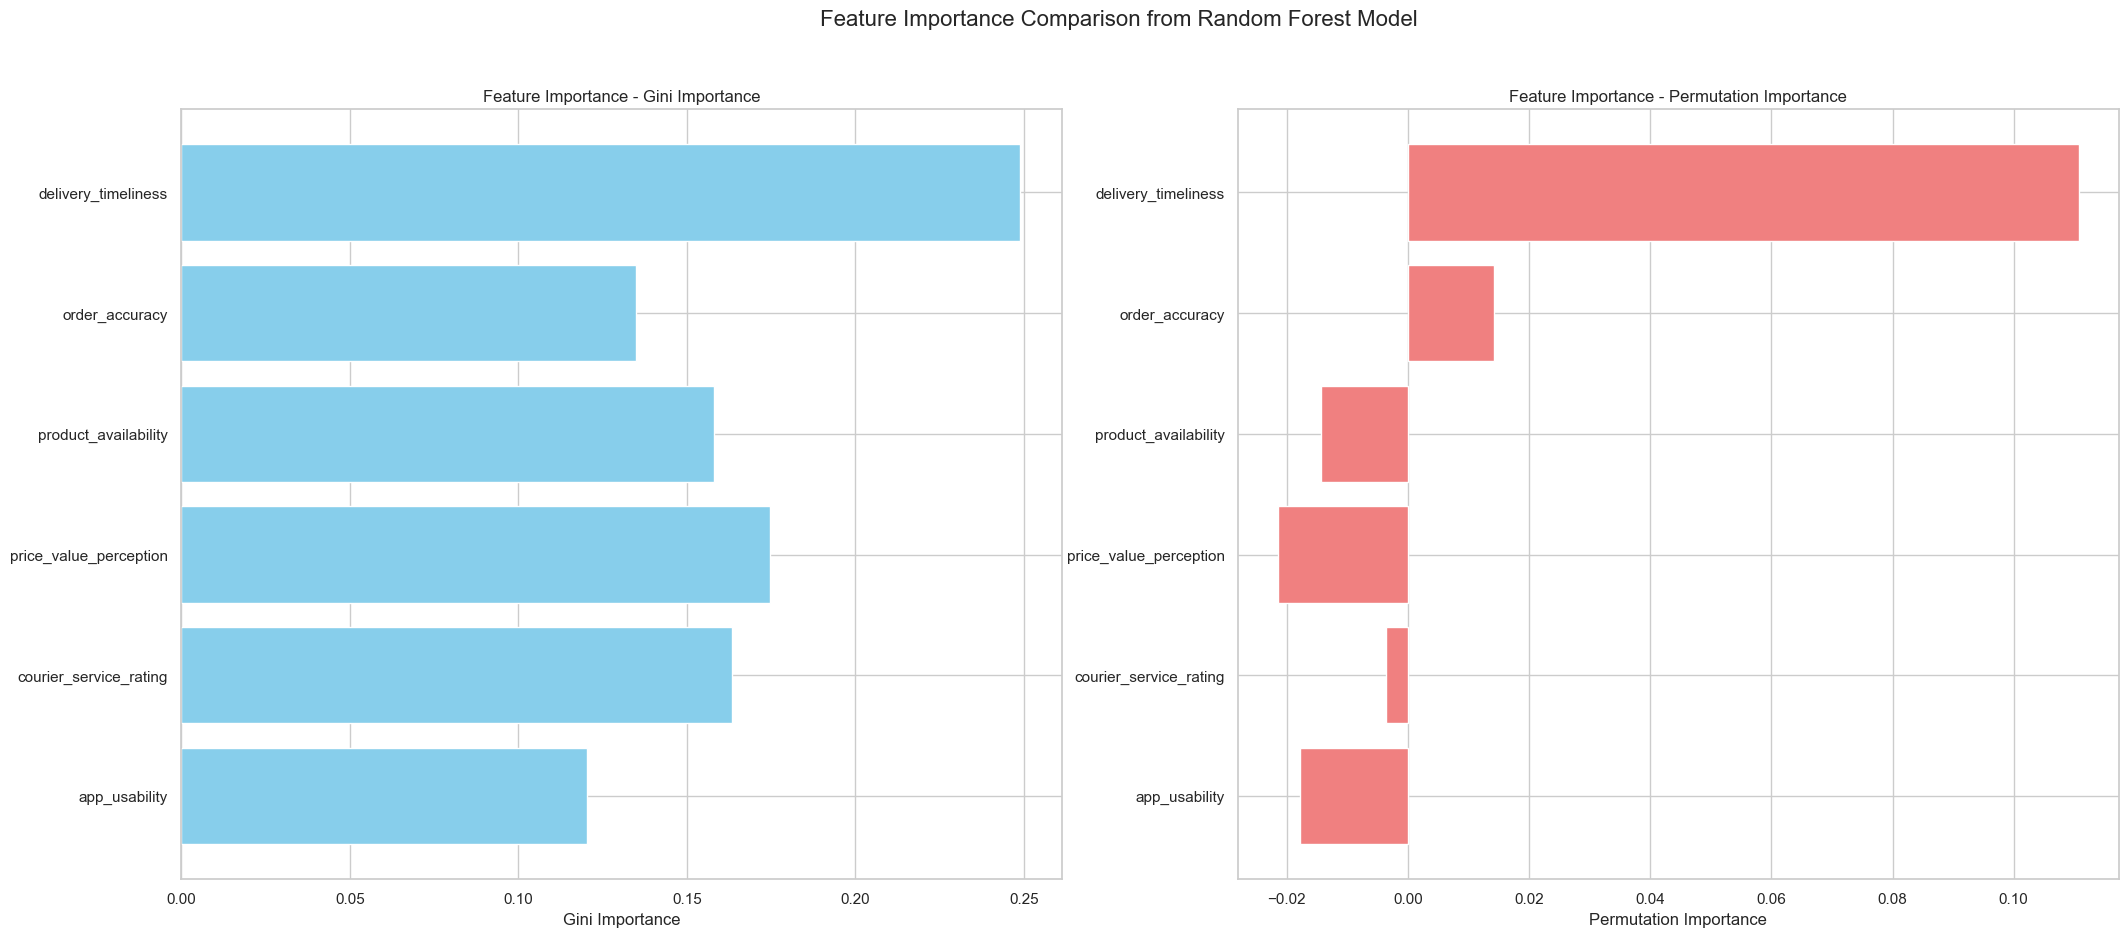

In [54]:
fig, ax = plt.subplots(1,2, figsize=(25, 10))

ax[0].barh(X.columns, importances, color='skyblue')
ax[0].set_xlabel('Gini Importance')
ax[0].set_title('Feature Importance - Gini Importance')
ax[0].invert_yaxis()

ax[1].barh(X.columns, feature_importance_df['Permutation Importance'], color='lightcoral')
ax[1].set_xlabel('Permutation Importance')
ax[1].set_title('Feature Importance - Permutation Importance')
ax[1].invert_yaxis()

fig.suptitle('Feature Importance Comparison from Random Forest Model', fontsize=16)
plt.show()

This would indicate that delivery_timeliness and courier_service_ratings are the two most relevant factors

Random Forest Feature Selection

In [55]:
RFECV_rf = RFECV(
    estimator=rf, 
    min_features_to_select=3, 
    step=1, 
    cv=StratifiedKFold(5, shuffle=True, random_state=42), 
    scoring='accuracy',
    )

RFECV_rf.fit(X_train, y_train)
y_pred_rfecv = RFECV_rf.predict(X_test)
print("=== RFECV FEATURE SELECTION RESULTS ===")
print(f"Optimal number of features: {RFECV_rf.n_features_}")
print(f"Selected features: {X.columns[RFECV_rf.support_].tolist()}")
print(f"Test F1 score: {f1_score(y_test, y_pred_rfecv):.2%}")
print(f"Test accuracy: {RFECV_rf.score(X_test, y_test)*100:.2f}%")


=== RFECV FEATURE SELECTION RESULTS ===
Optimal number of features: 3
Selected features: ['delivery_timeliness', 'product_availability', 'price_value_perception']
Test F1 score: 66.67%
Test accuracy: 64.29%


Random Forest Finetuning

In [56]:

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "max_depth": [2, 3, 4],  
    "n_estimators": [50, 100, 200], 
    "max_features": ["sqrt", "log2", None],
    "min_samples_leaf": [2, 5, 10],
    "criterion": ["gini", "entropy"],
    "class_weight": ['balanced', None]
}

grid = GridSearchCV(
    rf,
    param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1
)
grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)

print(f"Best parameters: {grid.best_params_}")
print(f"Best cross-validation accuracy: {grid.best_score_:.2%}")
print(f"Test F1 score: {f1_score(y_test, y_pred):.2%}")
print(f"Test accuracy: {grid.score(X_test, y_test):.2%}")

Best parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 200}
Best cross-validation accuracy: 59.63%
Test F1 score: 60.00%
Test accuracy: 57.14%


An accuracy of 64.29% is the highest accuracy attainable if duplicates are dropped

In [57]:
# Reload raw data so duplicates are kept (the earlier df was deduplicated in place)
df_full = pd.read_csv(file_path)
df_full.columns = ['customer_happiness', 'delivery_timeliness', 'order_accuracy',
    'product_availability', 'price_value_perception',
    'courier_service_rating', 'app_usability']

print(f"Shape with duplicates kept: {df_full.shape}")
print(f"Duplicate rows still present: {df_full.duplicated().sum()}\n")

# Train/test split (same settings as the deduplicated workflow)
X_full = df_full.drop(columns=['customer_happiness'])
y_full = df_full['customer_happiness']
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full, test_size=0.25, random_state=42, stratify=y_full)

# --- Baseline Random Forest ---
rf_full = RandomForestClassifier(max_depth=3, n_estimators=100,
    class_weight='balanced', random_state=42)
rf_full.fit(X_train_f, y_train_f)
y_pred_full = rf_full.predict(X_test_f)

print("=== BASELINE RANDOM FOREST (duplicates kept) ===")
print(f"Test F1 score: {f1_score(y_test_f, y_pred_full):.2%}")
print(f"Test accuracy: {accuracy_score(y_test_f, y_pred_full):.2%}\n")

# --- Feature importance ---
importances_full = rf_full.feature_importances_
perm_result_full = permutation_importance(
    rf_full, X_test_f, y_test_f, n_repeats=10, random_state=42, n_jobs=-1)
feature_importance_full = pd.DataFrame({
    'Feature': X_full.columns,
    'Gini Importance': importances_full,
    'Permutation Importance': perm_result_full.importances_mean})
print("=== FEATURE IMPORTANCE (duplicates kept) ===")
print(feature_importance_full.sort_values('Gini Importance', ascending=False).to_string(index=False))
print()

# --- Tuned Random Forest (grid search) ---
rf_tune = RandomForestClassifier(random_state=42)
param_grid_full = {
    "max_depth": [2, 3, 4],
    "n_estimators": [50, 100, 200],
    "max_features": ["sqrt", "log2", None],
    "min_samples_leaf": [2, 5, 10],
    "criterion": ["gini", "entropy"],
    "class_weight": ['balanced', None]
}
grid_full = GridSearchCV(
    rf_tune,
    param_grid_full,
    scoring='accuracy',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1
)
grid_full.fit(X_train_f, y_train_f)
y_pred_grid_full = grid_full.predict(X_test_f)

print("=== TUNED RANDOM FOREST (duplicates kept) ===")
print(f"Best parameters: {grid_full.best_params_}")
print(f"Best cross-validation accuracy: {grid_full.best_score_:.2%}")
print(f"Test F1 score: {f1_score(y_test_f, y_pred_grid_full):.2%}")
print(f"Test accuracy: {grid_full.score(X_test_f, y_test_f):.2%}")

Shape with duplicates kept: (126, 7)
Duplicate rows still present: 16

=== BASELINE RANDOM FOREST (duplicates kept) ===
Test F1 score: 84.21%
Test accuracy: 81.25%

=== FEATURE IMPORTANCE (duplicates kept) ===
               Feature  Gini Importance  Permutation Importance
courier_service_rating           0.1943                  0.1000
price_value_perception           0.1818                  0.0125
  product_availability           0.1701                  0.0563
   delivery_timeliness           0.1605                  0.1531
        order_accuracy           0.1522                  0.0406
         app_usability           0.1411                  0.0000

=== TUNED RANDOM FOREST (duplicates kept) ===
Best parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 50}
Best cross-validation accuracy: 56.43%
Test F1 score: 81.08%
Test accuracy: 78.12%


# Summary

With duplicates, accuracy rises to 81.25% in baseline random forest and 78.12% in tuned random forest